# Income Classification Using Demographic and Socio-Economic Features
### UCI Adult (Census Income) Dataset — MSc Dissertation Project

**Dataset:** UCI Adult (Census Income) · [UCI ML Repository](https://archive.ics.uci.edu/dataset/2/adult)  
**Target:** Predict whether income is `<=50K` or `>50K` per year  
**Approach:** Supervised binary classification using three models

---

## 1. Introduction

Understanding what drives income inequality is a core concern in social policy and economics. The UCI Adult dataset, compiled from the 1994 US Census Bureau, provides 14 demographic and socio-economic attributes for 32,561 individuals. It is a widely used benchmark for binary classification and allows us to examine which personal and occupational factors most strongly predict whether someone earns above \$50,000 per year.

This notebook addresses three research questions:

| # | Research Question |
|---|---|
| **RQ1** | How accurately can demographic and socio-economic features predict income class (above or below \$50K)? |
| **RQ2** | Among Logistic Regression, Decision Tree, and Random Forest — which performs best on Accuracy, Precision, Recall, and F1? |
| **RQ3** | Which features most influence income prediction, and are those findings consistent across all three models? |

**Project scope:** Exactly three classifiers are compared. This is a deliberate constraint to keep the study focused, reproducible, and straightforward to defend.

**Workflow:**
```
Data Loading  →  Missing Values  →  EDA  →  Preprocessing Pipeline
→  3-Model Training  →  Evaluation  →  Hyperparameter Tuning
→  Feature Importance (3 methods)  →  Research Question Answers
```


## 2. Imports and Configuration

All libraries are loaded in a single cell. `random_state = 42` is used everywhere to guarantee full reproducibility — running the notebook from top to bottom will always produce identical results.


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Scikit-learn — pipelines, preprocessing, models, evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, ConfusionMatrixDisplay, classification_report
)

# ── Global constants ───────────────────────────────
SEED = 42
np.random.seed(SEED)

# One colour per model — used consistently in every plot
COLOURS = {
    'Logistic Regression': '#4c78a8',
    'Decision Tree':       '#f58518',
    'Random Forest':       '#54a24b'
}

DATA_PATH = r"C:\Users\User\Downloads\adult.data"

COLS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

# Clean plot style throughout
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold'
})

print('Libraries loaded  |  Seed =', SEED)


Libraries loaded  |  Seed = 42


## 3. Dataset Overview

### 3.1 Loading the Data

The raw file is comma-separated with a leading space after each comma. `skipinitialspace=True` strips that space automatically.

> **⚠ Important — missing value encoding:**  
> Because `skipinitialspace=True` strips the leading space *before* pandas checks `na_values`, missing entries appear in memory as `'?'` (not `' ?'`).  
> Using `na_values=' ?'` is a silent bug — it reports **zero** missing values while encoding `?` as a valid string category, corrupting imputation and feature importance.  
> The correct setting is `na_values='?'`.


In [3]:
df = pd.read_csv(
    DATA_PATH,
    header=None,
    names=COLS,
    na_values='?',          # correct — space already stripped by skipinitialspace
    skipinitialspace=True
)

# Strip whitespace and trailing '.' from income labels
df['income'] = df['income'].str.strip().str.rstrip('.')

print(f'Shape: {df.shape[0]:,} rows  x  {df.shape[1]} columns')


Shape: 32,561 rows  x  15 columns


In [4]:
# Preview the first five records
df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data types — confirms numeric vs categorical split before preprocessing
print(df.dtypes)


age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object


### 3.2 Missing Values

Three columns carry missing values (`?` in the raw file). Rather than dropping rows, the preprocessing pipeline in Section 4 handles these via imputation, keeping all 32,561 records available for training.


In [6]:
# Compute counts and percentages
missing     = df.isna().sum().rename('Missing')
missing_pct = (df.isna().mean() * 100).rename('Missing %').round(2)
miss_table  = pd.concat([missing, missing_pct], axis=1).sort_values('Missing', ascending=False)

print(miss_table)
print(f'\nTotal missing: {missing.sum():,} cells '
      f'({missing.sum() / df.size * 100:.2f}% of all values)')
print(f'Affected columns: {list(missing[missing > 0].index)}')


                Missing  Missing %
occupation         1843       5.66
workclass          1836       5.64
native_country      583       1.79
fnlwgt                0       0.00
education             0       0.00
education_num         0       0.00
age                   0       0.00
marital_status        0       0.00
relationship          0       0.00
sex                   0       0.00
race                  0       0.00
capital_gain          0       0.00
capital_loss          0       0.00
hours_per_week        0       0.00
income                0       0.00

Total missing: 4,262 cells (0.87% of all values)
Affected columns: ['workclass', 'occupation', 'native_country']


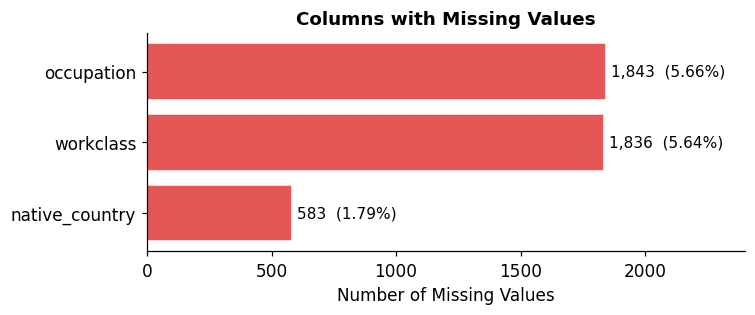

In [7]:
# Bar chart of missing values
miss_plot = miss_table[miss_table['Missing'] > 0]

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(miss_plot.index, miss_plot['Missing'], color='#e45756', edgecolor='white')
for i, (idx, row) in enumerate(miss_plot.iterrows()):
    ax.text(row['Missing'] + 20, i,
            f"{int(row['Missing']):,}  ({row['Missing %']}%)",
            va='center', fontsize=10)
ax.set_xlabel('Number of Missing Values')
ax.set_title('Columns with Missing Values')
ax.set_xlim(0, 2400)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### 3.3 Target Variable & Class Imbalance

The target is binary: `<=50K` (majority, ~76%) vs `>50K` (minority, ~24%). A trivial classifier that always predicts `<=50K` would score 76% accuracy without learning anything — so **Accuracy alone is not a reliable metric here**. We use **F1-score** as the primary metric (balances precision and recall) and **ROC-AUC** to assess discrimination across all probability thresholds.


In [8]:
income_counts = df['income'].value_counts()
minority_pct  = income_counts['>50K'] / income_counts.sum() * 100

print('Income distribution:')
for label, count in income_counts.items():
    print(f'  {label:6s}: {count:,}  ({count / len(df) * 100:.1f}%)')
print(f'\nImbalance ratio: {income_counts["<=50K"] / income_counts[">50K"]:.2f} : 1')
print('Primary evaluation metric: F1-score (handles imbalanced classes)')


Income distribution:
  <=50K : 24,720  (75.9%)
  >50K  : 7,841  (24.1%)

Imbalance ratio: 3.15 : 1
Primary evaluation metric: F1-score (handles imbalanced classes)


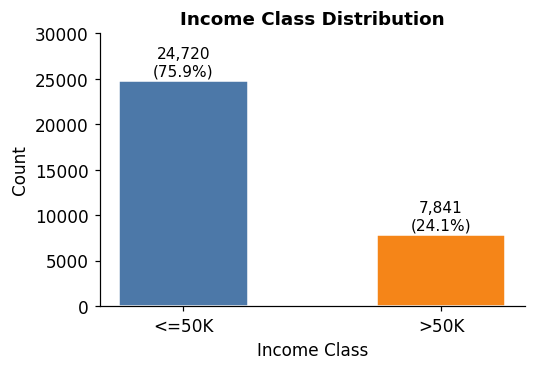

In [9]:
# Class distribution bar chart
fig, ax = plt.subplots(figsize=(5, 3.5))
bars = ax.bar(income_counts.index, income_counts.values,
              color=['#4c78a8', '#f58518'], edgecolor='white', width=0.5)
for bar in bars:
    pct = bar.get_height() / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 250,
            f'{int(bar.get_height()):,}\n({pct:.1f}%)',
            ha='center', va='bottom', fontsize=10)
ax.set_title('Income Class Distribution')
ax.set_xlabel('Income Class')
ax.set_ylabel('Count')
ax.set_ylim(0, 30000)
plt.tight_layout()
plt.show()


### 3.4 Exploratory Data Analysis (EDA)

EDA focuses on features most likely to matter for RQ3. We look at the relationship between income class and the strongest demographic predictors. Observations here are revisited in the Feature Importance section.


**EDA Part A — Age and Hours per Week**

Continuous numeric features. We expect older workers and those working longer hours to have higher incomes.


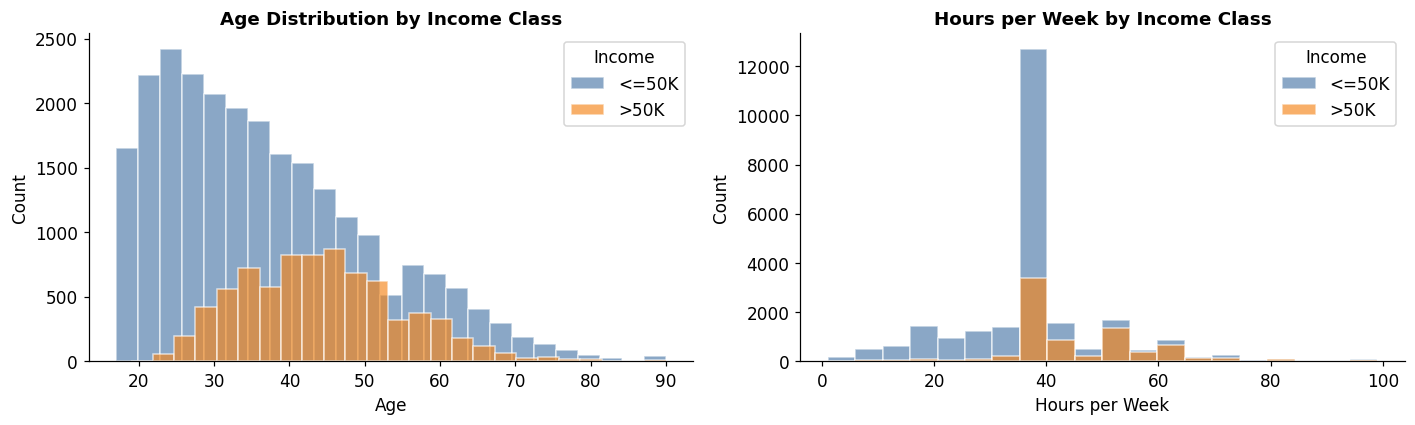

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {'<=50K': '#4c78a8', '>50K': '#f58518'}

# Age distribution by income
for label, col in palette.items():
    axes[0].hist(df[df['income'] == label]['age'], bins=25,
                 alpha=0.65, label=label, color=col, edgecolor='white')
axes[0].set_title('Age Distribution by Income Class')
axes[0].set_xlabel('Age'); axes[0].set_ylabel('Count')
axes[0].legend(title='Income')

# Hours per week distribution
for label, col in palette.items():
    axes[1].hist(df[df['income'] == label]['hours_per_week'], bins=20,
                 alpha=0.65, label=label, color=col, edgecolor='white')
axes[1].set_title('Hours per Week by Income Class')
axes[1].set_xlabel('Hours per Week'); axes[1].set_ylabel('Count')
axes[1].legend(title='Income')

plt.tight_layout()
plt.show()


**EDA Part B — Education and Marital Status**

Categorical features with strong expected associations. Higher education typically predicts higher income; marital status proxies for household financial context.


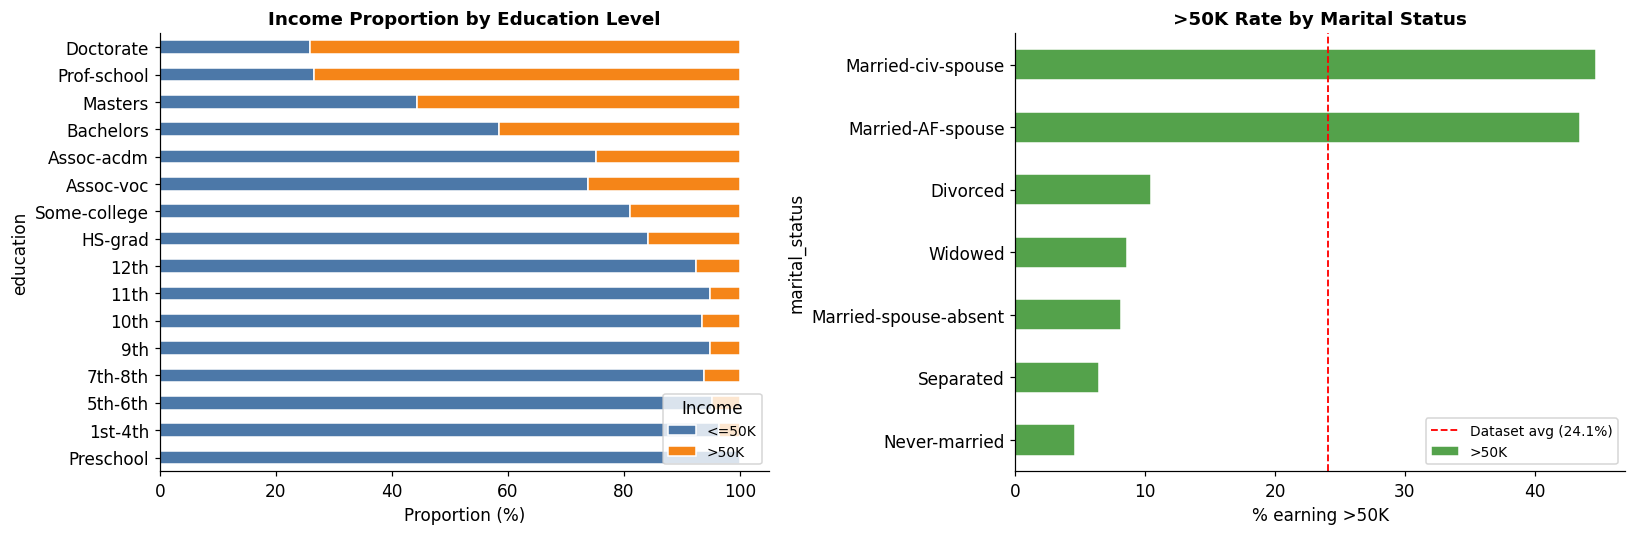

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Education: stacked % bar ordered from least to most educated
edu_order = ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th',
             '12th','HS-grad','Some-college','Assoc-voc','Assoc-acdm',
             'Bachelors','Masters','Prof-school','Doctorate']
edu_order = [e for e in edu_order if e in df['education'].unique()]
edu_cross = pd.crosstab(df['education'], df['income'], normalize='index') * 100
edu_cross  = edu_cross.reindex([e for e in edu_order if e in edu_cross.index])
edu_cross.plot(kind='barh', stacked=True, ax=axes[0],
               color=['#4c78a8','#f58518'], edgecolor='white', legend=False)
axes[0].set_title('Income Proportion by Education Level')
axes[0].set_xlabel('Proportion (%)')
axes[0].legend(['<=50K', '>50K'], title='Income', loc='lower right', fontsize=9)

# Marital status: % earning >50K
ms_rate = pd.crosstab(df['marital_status'], df['income'], normalize='index') * 100
ms_rate['>50K'].sort_values().plot(kind='barh', ax=axes[1],
                                   color='#54a24b', edgecolor='white')
axes[1].axvline(minority_pct, color='red', lw=1.2, ls='--',
                label=f'Dataset avg ({minority_pct:.1f}%)')
axes[1].set_title('>50K Rate by Marital Status')
axes[1].set_xlabel('% earning >50K')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


**EDA Part C — Capital Gain and Sex**

Capital gain is highly skewed (most values are zero), but non-zero values are disproportionately associated with high income. Sex shows a notable disparity in >50K rates.


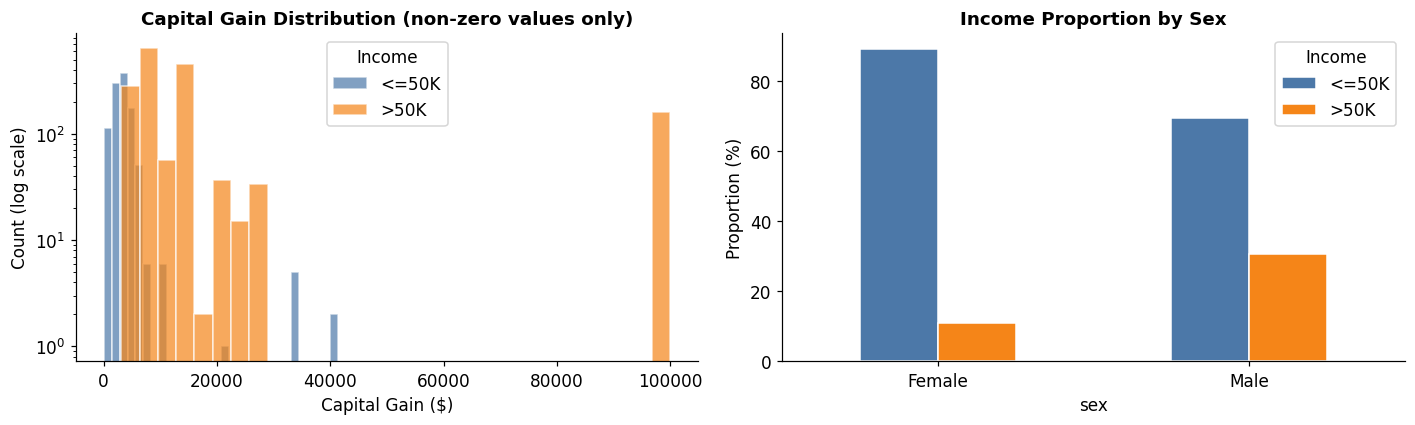

Key EDA takeaways:
  • Education level has a clear positive gradient with income
  • Married-civ-spouse far exceeds the average >50K rate (~45% vs 24%)
  • Non-zero capital gain is a strong >50K signal
  • Males show nearly 3x the >50K rate of females in this dataset


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Capital gain: non-zero values only, log scale
for label, col in palette.items():
    cg = df[df['income'] == label]['capital_gain']
    axes[0].hist(cg[cg > 0], bins=30, alpha=0.7,
                 label=label, color=col, edgecolor='white')
axes[0].set_title('Capital Gain Distribution (non-zero values only)')
axes[0].set_xlabel('Capital Gain ($)')
axes[0].set_ylabel('Count (log scale)')
axes[0].set_yscale('log')
axes[0].legend(title='Income')

# Sex: income proportion
sex_cross = pd.crosstab(df['sex'], df['income'], normalize='index') * 100
sex_cross.plot(kind='bar', ax=axes[1], color=['#4c78a8','#f58518'],
               edgecolor='white', legend=True)
axes[1].set_title('Income Proportion by Sex')
axes[1].set_ylabel('Proportion (%)')
axes[1].set_xticklabels(sex_cross.index, rotation=0)
axes[1].legend(title='Income')

plt.tight_layout()
plt.show()

print('Key EDA takeaways:')
print('  • Education level has a clear positive gradient with income')
print('  • Married-civ-spouse far exceeds the average >50K rate (~45% vs 24%)')
print('  • Non-zero capital gain is a strong >50K signal')
print('  • Males show nearly 3x the >50K rate of females in this dataset')


## 4. Preprocessing Pipeline

### 4.1 Feature and Target Definition

The target `income` is encoded as a binary integer (1 = `>50K`, 0 = `<=50K`).  
`fnlwgt` is excluded — it is a census *sampling weight* assigned to demographic groups, not an individual attribute, so it would distort feature importance without adding predictive meaning.


In [13]:
# Binary target
y = (df['income'] == '>50K').astype(int)

# Feature matrix — drop target and census weight
X = df.drop(columns=['income', 'fnlwgt'])

# Separate numeric and categorical columns by dtype
NUM_COLS = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
CAT_COLS = X.select_dtypes(include=['object']).columns.tolist()

print('Numeric features  :', NUM_COLS)
print('Categorical features:', CAT_COLS)
print(f'\nTarget: 1 = >50K ({y.sum():,})  |  0 = <=50K ({(y==0).sum():,})')


Numeric features  : ['age', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Categorical features: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']

Target: 1 = >50K (7,841)  |  0 = <=50K (24,720)


### 4.2 Train / Test Split

An 80/20 stratified split is used. `stratify=y` ensures both sets have the same ~24% minority class proportion as the full dataset.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Train >50K ratio: {y_train.mean():.4f}')
print(f'Test  >50K ratio: {y_test.mean():.4f}')
print('Stratification confirmed — class ratio preserved in both sets.')


Train: 26,048 rows  |  Test: 6,513 rows
Train >50K ratio: 0.2408
Test  >50K ratio: 0.2407
Stratification confirmed — class ratio preserved in both sets.


### 4.3 Pipeline Design

| Step | Numeric features | Categorical features | Why |
|------|-----------------|----------------------|-----|
| **Imputation** | Median | Most-frequent (mode) | Median is robust to skewed distributions; mode preserves the most common category |
| **Scaling** | StandardScaler | — | Required by Logistic Regression; harmless for tree models |
| **Encoding** | — | OneHotEncoder (`handle_unknown='ignore'`) | Converts categories to binary flags; ignores any unseen category at test time |

**No leakage:** The pipeline is fitted only on `X_train`. Imputation statistics, scaling parameters, and OHE categories are computed from training data alone and then applied to `X_test`.


In [15]:
# Individual sub-pipelines
numeric_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a ColumnTransformer
preprocess = ColumnTransformer([
    ('num', numeric_pipe, NUM_COLS),
    ('cat', categorical_pipe, CAT_COLS)
])

# Cross-validation strategy — shared by all models and GridSearchCV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('Preprocessing pipeline constructed.')
print('It will be fitted inside each Pipeline object — no leakage possible.')


Preprocessing pipeline constructed.
It will be fitted inside each Pipeline object — no leakage possible.


## 5. Model Training — Exactly 3 Models

### 5.1 Model Definitions

Three classifiers are chosen to represent different families of supervised learning:

| Model | Type | Key strength | Requires scaling? |
|---|---|---|---|
| **Logistic Regression** | Linear | Interpretable coefficients; strong probabilistic output | Yes |
| **Decision Tree** | Non-linear | Fully transparent decision rules; no scaling needed | No |
| **Random Forest** | Ensemble | Best typical performance on tabular data; reduces overfitting via bagging | No |

Each model is wrapped in a complete `Pipeline(preprocessing → model)` so the preprocessor is re-fitted inside each cross-validation fold — preventing any form of data leakage.


In [16]:
BASE_MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=200,
                                                  random_state=SEED, n_jobs=-1)
}

# Storage dictionaries
fitted     = {}   # fitted Pipeline objects
pred_store = {}   # test-set predictions
prob_store = {}   # test-set probabilities
results    = []   # metrics rows

print('Training models...')
for name, model in BASE_MODELS.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    fitted[name]     = pipe
    pred_store[name] = pred
    prob_store[name] = proba

    results.append({
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred, zero_division=0),
        'Recall':    recall_score(y_test, pred, zero_division=0),
        'F1':        f1_score(y_test, pred, zero_division=0),
        'ROC_AUC':   roc_auc_score(y_test, proba)
    })
    print(f'  {name:25s} done.')

print('All models trained.')


Training models...
  Logistic Regression       done.
  Decision Tree             done.
  Random Forest             done.
All models trained.


### 5.2 Performance Summary Table

Models are ranked by F1-score. The baseline column shows what a trivial majority-class classifier achieves (always predicts `<=50K`).


In [18]:
results_df = (pd.DataFrame(results)
              .sort_values('F1', ascending=False)
              .reset_index(drop=True))

# Model order list (used by later cells)
model_order = results_df['Model'].tolist()

# Majority-class baseline for reference
baseline_acc = (y_test == 0).mean()
baseline_f1  = 0.0

print('=' * 68)
print('BASE MODEL RESULTS — Hold-out Test Set (ranked by F1)')
print('=' * 68)
print(results_df.to_string(index=False, float_format='{:.4f}'.format))
print('=' * 68)
print(f'\nMajority-class baseline:  Accuracy = {baseline_acc:.4f}  F1 = {baseline_f1:.4f}')
print(f'Best model by F1  : {results_df.iloc[0]["Model"]}  (F1 = {results_df.iloc[0]["F1"]:.4f})')
print(f'Best model by AUC : {results_df.loc[results_df["ROC_AUC"].idxmax(), "Model"]}  (AUC = {results_df["ROC_AUC"].max():.4f})')


BASE MODEL RESULTS — Hold-out Test Set (ranked by F1)
              Model  Accuracy  Precision  Recall     F1  ROC_AUC
      Random Forest    0.8489     0.7051  0.6403 0.6711   0.8945
Logistic Regression    0.8544     0.7381  0.6129 0.6697   0.9077
      Decision Tree    0.8165     0.6199  0.6148 0.6174   0.7673

Majority-class baseline:  Accuracy = 0.7593  F1 = 0.0000
Best model by F1  : Random Forest  (F1 = 0.6711)
Best model by AUC : Logistic Regression  (AUC = 0.9077)


### 5.3 Metric Comparison Chart

A grouped bar chart shows all four metrics side-by-side for each model. The dashed red line marks the majority-class accuracy baseline (0.761) — anything below this line is no better than the trivial classifier.


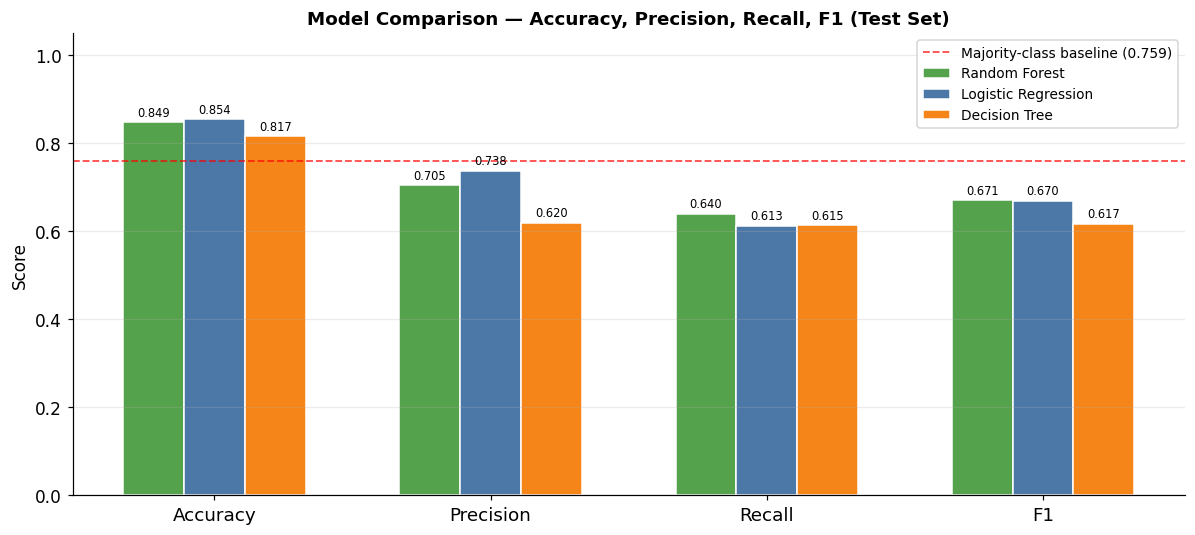

In [19]:
METRICS = ['Accuracy', 'Precision', 'Recall', 'F1']

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(METRICS))
w = 0.22

for i, (_, row) in enumerate(results_df.iterrows()):
    offset = (i - len(BASE_MODELS) / 2 + 0.5) * w
    bars   = ax.bar(x + offset, [row[m] for m in METRICS], w,
                    label=row['Model'], color=COLOURS[row['Model']], edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.007,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7.5)

ax.axhline(baseline_acc, color='red', lw=1.2, ls='--', alpha=0.7,
           label=f'Majority-class baseline ({baseline_acc:.3f})')
ax.set_xticks(x)
ax.set_xticklabels(METRICS, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy, Precision, Recall, F1 (Test Set)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.25)
plt.tight_layout()
plt.show()


### 5.4 ROC and Precision-Recall Curves

- **ROC curve:** plots True Positive Rate vs False Positive Rate at every threshold. Higher AUC = better discrimination.
- **Precision-Recall curve:** more informative for imbalanced classes. The dashed red line marks the no-skill baseline (precision = minority class proportion = 0.241).


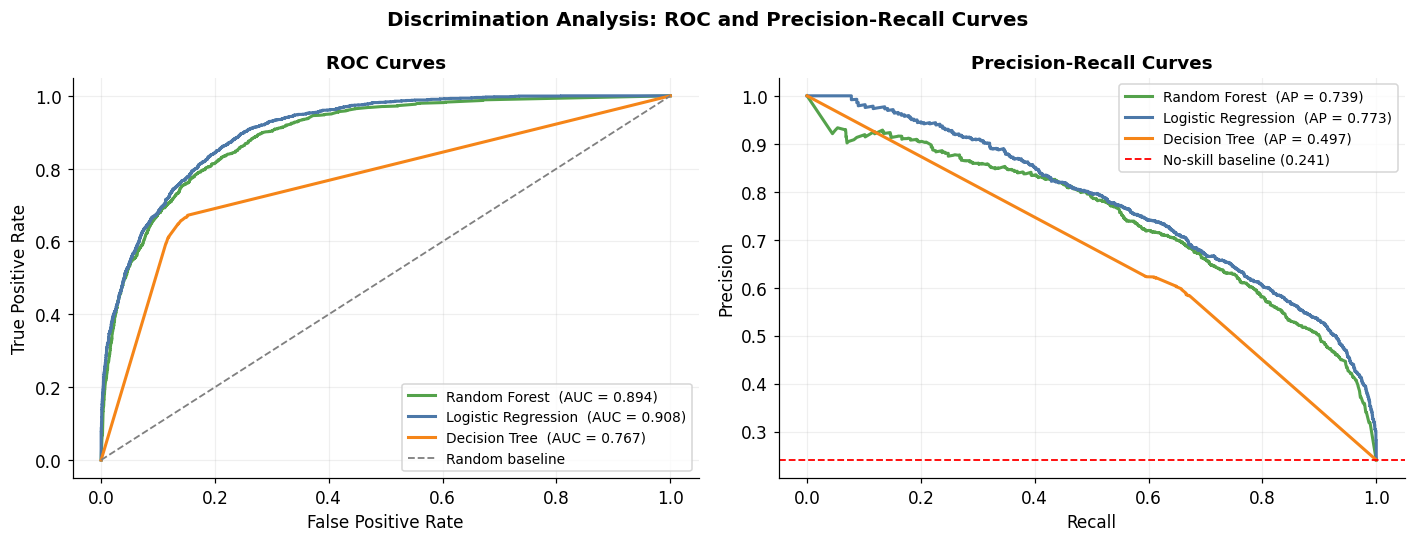

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in model_order:
    # ROC
    fpr, tpr, _ = roc_curve(y_test, prob_store[name])
    auc_val      = roc_auc_score(y_test, prob_store[name])
    axes[0].plot(fpr, tpr, color=COLOURS[name], lw=2,
                 label=f'{name}  (AUC = {auc_val:.3f})')

    # Precision-Recall
    prec, rec, _ = precision_recall_curve(y_test, prob_store[name])
    ap            = average_precision_score(y_test, prob_store[name])
    axes[1].plot(rec, prec, color=COLOURS[name], lw=2,
                 label=f'{name}  (AP = {ap:.3f})')

# ROC baseline
axes[0].plot([0,1],[0,1], '--', color='grey', lw=1.2, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(alpha=0.2)

# PR baseline
axes[1].axhline(y_test.mean(), color='red', lw=1.2, ls='--',
                label=f'No-skill baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(alpha=0.2)

plt.suptitle('Discrimination Analysis: ROC and Precision-Recall Curves',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.5 Confusion Matrices

Each confusion matrix shows the raw prediction counts. Rows are actual classes; columns are predicted classes. The key trade-off for imbalanced data is between **False Negatives** (high-income individuals wrongly classified as low-income) and **False Positives** (low-income individuals wrongly classified as high-income).


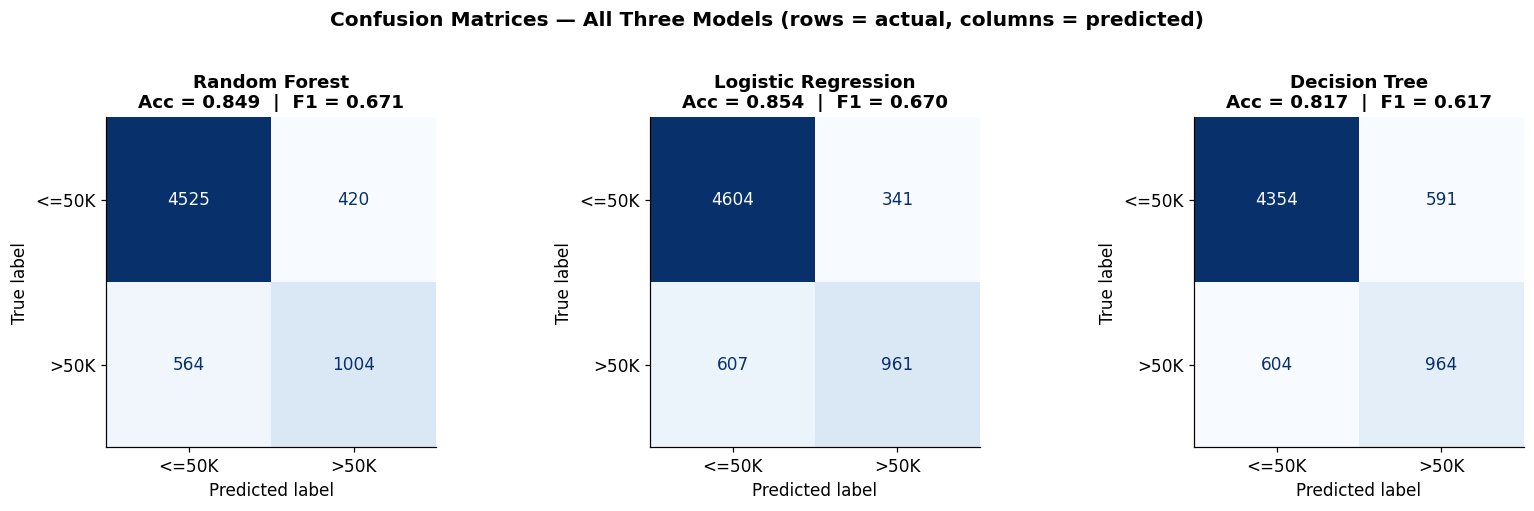

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for i, name in enumerate(model_order):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred_store[name],
        display_labels=['<=50K', '>50K'],
        cmap='Blues', colorbar=False, ax=axes[i]
    )
    acc = accuracy_score(y_test, pred_store[name])
    f1  = f1_score(y_test, pred_store[name])
    axes[i].set_title(f'{name}\nAcc = {acc:.3f}  |  F1 = {f1:.3f}')

fig.suptitle('Confusion Matrices — All Three Models (rows = actual, columns = predicted)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 5.6 Full Classification Reports

Per-class precision, recall, and F1 for both income classes. This completes the base model evaluation required by RQ2.


In [22]:
for name in model_order:
    print(f'{"=" * 55}')
    print(f'  {name}')
    print(f'{"=" * 55}')
    print(classification_report(y_test, pred_store[name],
                                target_names=['<=50K', '>50K'],
                                zero_division=0))


  Random Forest
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.90      4945
        >50K       0.71      0.64      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.80      0.78      0.79      6513
weighted avg       0.84      0.85      0.85      6513

  Logistic Regression
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4945
        >50K       0.74      0.61      0.67      1568

    accuracy                           0.85      6513
   macro avg       0.81      0.77      0.79      6513
weighted avg       0.85      0.85      0.85      6513

  Decision Tree
              precision    recall  f1-score   support

       <=50K       0.88      0.88      0.88      4945
        >50K       0.62      0.61      0.62      1568

    accuracy                           0.82      6513
   macro avg       0.75      0.75      0.75      6513
weighted avg       0

## 6. Hyperparameter Tuning

### 6.1 Grid Search Setup

The best-performing base model (by F1) is selected for tuning. GridSearchCV with 5-fold stratified cross-validation explores a targeted parameter grid. Scoring metric is `f1` to directly optimise for minority-class performance under class imbalance.


In [23]:
best_name = results_df.iloc[0]['Model']
print(f'Best base model by F1: {best_name}')
print('Defining parameter grid for tuning...')

if best_name == 'Logistic Regression':
    tune_pipe  = Pipeline([('prep', preprocess),
                           ('model', LogisticRegression(max_iter=2000, random_state=SEED))])
    param_grid = {
        'model__C':            [0.01, 0.1, 1.0, 5.0],
        'model__class_weight': [None, 'balanced']
    }

elif best_name == 'Decision Tree':
    tune_pipe  = Pipeline([('prep', preprocess),
                           ('model', DecisionTreeClassifier(random_state=SEED))])
    param_grid = {
        'model__max_depth':        [5, 10, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf':  [1, 2, 4]
    }

else:  # Random Forest
    tune_pipe  = Pipeline([('prep', preprocess),
                           ('model', RandomForestClassifier(random_state=SEED, n_jobs=-1))])
    param_grid = {
        'model__n_estimators':      [150, 250],
        'model__max_depth':         [None, 12, 20],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf':  [1, 2]
    }

n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f'Parameter combinations: {n_combos}  x  5 folds = {n_combos*5} fits')


Best base model by F1: Random Forest
Defining parameter grid for tuning...
Parameter combinations: 24  x  5 folds = 120 fits


In [24]:
# Run cross-validated grid search
grid = GridSearchCV(
    tune_pipe,
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=0
)
grid.fit(X_train, y_train)

print(f'Best parameters : {grid.best_params_}')
print(f'Best CV F1      : {grid.best_score_:.4f}')


Best parameters : {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 150}
Best CV F1      : 0.6856


### 6.2 Tuned Model — Metric Comparison vs Base

The tuned model is evaluated on the same held-out test set. The delta (Δ) column shows the change from the base model, confirming whether tuning helped.


In [25]:
best_pipe  = grid.best_estimator_
pred_tuned = best_pipe.predict(X_test)
prob_tuned = best_pipe.predict_proba(X_test)[:, 1]

tuned_metrics = {
    'Accuracy':  accuracy_score(y_test, pred_tuned),
    'Precision': precision_score(y_test, pred_tuned, zero_division=0),
    'Recall':    recall_score(y_test, pred_tuned, zero_division=0),
    'F1':        f1_score(y_test, pred_tuned, zero_division=0),
    'ROC_AUC':   roc_auc_score(y_test, prob_tuned)
}

base_row = results_df[results_df['Model'] == best_name].iloc[0]
print(f'Tuned {best_name} — Test Set Results')
print('-' * 50)
for metric, val in tuned_metrics.items():
    delta = val - base_row[metric]
    print(f'  {metric:12s}: {val:.4f}   (Δ {delta:+.4f})')


Tuned Random Forest — Test Set Results
--------------------------------------------------
  Accuracy    : 0.8690   (Δ +0.0201)
  Precision   : 0.7731   (Δ +0.0681)
  Recall      : 0.6454   (Δ +0.0051)
  F1          : 0.7035   (Δ +0.0324)
  ROC_AUC     : 0.9210   (Δ +0.0265)


### 6.3 Tuned Model — Confusion Matrix and ROC Curve

Side-by-side comparison: the confusion matrix shows absolute prediction counts for the tuned model; the ROC chart overlays base vs tuned to confirm improvement in discrimination.


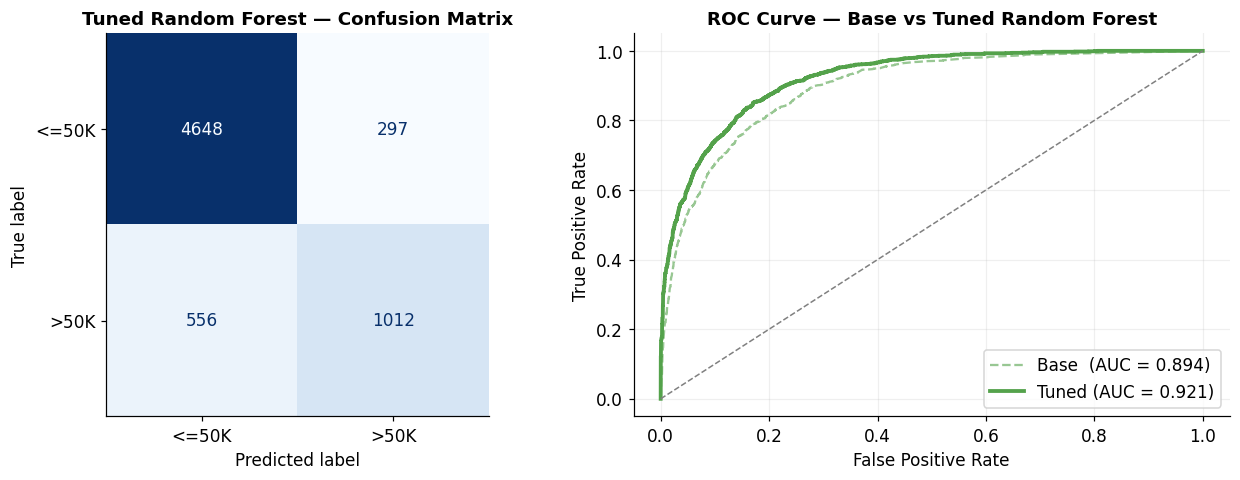

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_tuned,
    display_labels=['<=50K', '>50K'],
    cmap='Blues', colorbar=False, ax=axes[0]
)
axes[0].set_title(f'Tuned {best_name} — Confusion Matrix')

# ROC: base vs tuned overlay
fpr_b, tpr_b, _ = roc_curve(y_test, prob_store[best_name])
fpr_t, tpr_t, _ = roc_curve(y_test, prob_tuned)
auc_base  = roc_auc_score(y_test, prob_store[best_name])
auc_tuned = roc_auc_score(y_test, prob_tuned)

axes[1].plot(fpr_b, tpr_b, lw=1.5, ls='--', color=COLOURS[best_name], alpha=0.6,
             label=f'Base  (AUC = {auc_base:.3f})')
axes[1].plot(fpr_t, tpr_t, lw=2.5, color=COLOURS[best_name],
             label=f'Tuned (AUC = {auc_tuned:.3f})')
axes[1].plot([0,1],[0,1], '--', color='grey', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — Base vs Tuned {best_name}')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()


### 6.4 Complete Model Comparison Table

All models, including the tuned version, in one final summary table.


In [27]:
tuned_row = pd.DataFrame([{'Model': f'Tuned {best_name}', **tuned_metrics}])
summary_df = pd.concat([results_df, tuned_row], ignore_index=True)

print('Full model comparison — base models + tuned winner:')
print('=' * 68)
print(summary_df.to_string(index=False, float_format='{:.4f}'.format))
print('=' * 68)


Full model comparison — base models + tuned winner:
              Model  Accuracy  Precision  Recall     F1  ROC_AUC
      Random Forest    0.8489     0.7051  0.6403 0.6711   0.8945
Logistic Regression    0.8544     0.7381  0.6129 0.6697   0.9077
      Decision Tree    0.8165     0.6199  0.6148 0.6174   0.7673
Tuned Random Forest    0.8690     0.7731  0.6454 0.7035   0.9210


## 7. Feature Importance and Cross-Model Consistency (RQ3)

Three complementary importance methods are used. Using multiple methods guards against the known biases of any single method alone:

| Method | Applied to | What it measures | Known limitation |
|--------|-----------|-----------------|-----------------|
| **Coefficient magnitude** | Logistic Regression | Change in log-odds per unit/indicator | Spread across many OHE columns per original feature |
| **Gini impurity importance** | Decision Tree, Random Forest | Mean reduction in node impurity per feature | Overestimates high-cardinality features (e.g. `native_country`) |
| **Permutation importance** | All 3 models | F1 drop when feature values are shuffled | Reduced signal when features are correlated |

For cross-model comparison, Gini and permutation importances are **aggregated back to the original feature level** (summing across all OHE dummies), so all three models are compared on the same 13-feature space.


### 7.1 Logistic Regression — Coefficient-Based Importance

Coefficients show the direction and magnitude of each feature's effect on the log-odds of earning `>50K`. Orange bars increase the probability; blue bars decrease it.


In [28]:
# Extract OHE feature names from the fitted pipeline
def get_ohe_names(pipeline):
    prep = pipeline.named_steps['prep']
    ohe  = prep.named_transformers_['cat'].named_steps['onehot']
    return NUM_COLS + list(ohe.get_feature_names_out(CAT_COLS))

ohe_names = get_ohe_names(fitted['Logistic Regression'])
print(f'Features after OHE: {len(ohe_names)}  (from {X.shape[1]} originals)')


Features after OHE: 104  (from 13 originals)


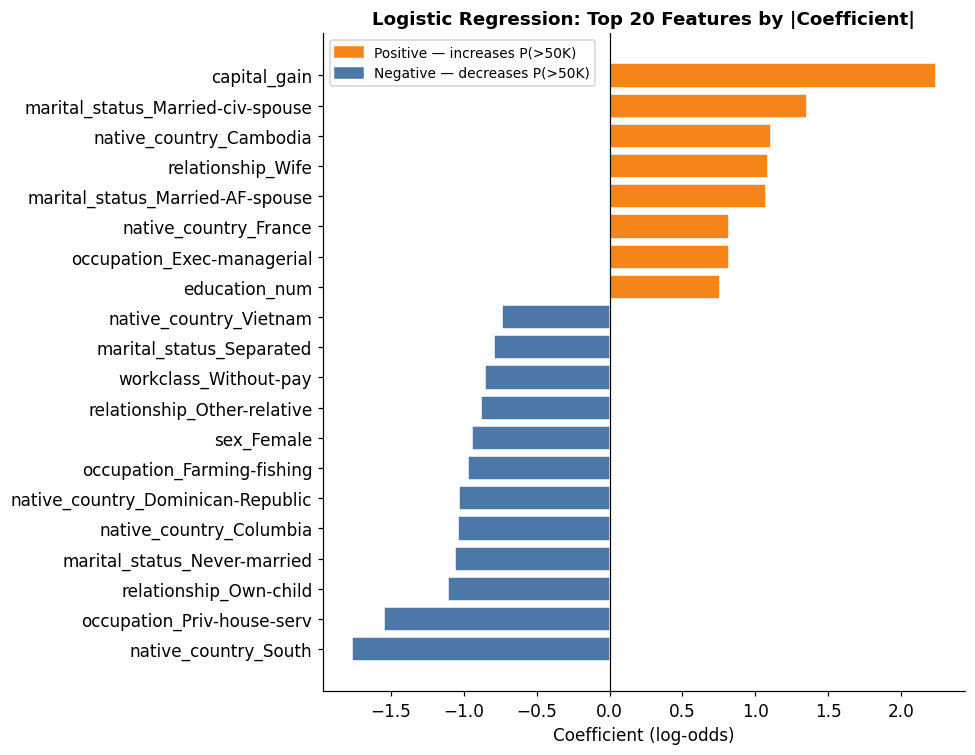

In [29]:
lr_model = fitted['Logistic Regression'].named_steps['model']
lr_df = pd.DataFrame({'feature': ohe_names, 'coef': lr_model.coef_[0]})
lr_df['abs_coef'] = lr_df['coef'].abs()

lr_top = lr_df.nlargest(20, 'abs_coef').sort_values('coef')
bar_colours = ['#f58518' if c > 0 else '#4c78a8' for c in lr_top['coef']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(lr_top['feature'], lr_top['coef'], color=bar_colours, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Logistic Regression: Top 20 Features by |Coefficient|')
pos_p = mpatches.Patch(color='#f58518', label='Positive — increases P(>50K)')
neg_p = mpatches.Patch(color='#4c78a8', label='Negative — decreases P(>50K)')
ax.legend(handles=[pos_p, neg_p], fontsize=9)
plt.tight_layout()
plt.show()


In [30]:
# Print top positive and top negative features
print('Top 8 income-INCREASING features (LR):')
print(lr_df.sort_values('coef', ascending=False).head(8)[['feature','coef']].to_string(index=False))

print('\nTop 8 income-DECREASING features (LR):')
print(lr_df.sort_values('coef').head(8)[['feature','coef']].to_string(index=False))


Top 8 income-INCREASING features (LR):
                          feature     coef
                     capital_gain 2.235766
marital_status_Married-civ-spouse 1.356923
          native_country_Cambodia 1.105650
                relationship_Wife 1.089377
 marital_status_Married-AF-spouse 1.073940
            native_country_France 0.821931
       occupation_Exec-managerial 0.817521
                    education_num 0.756422

Top 8 income-DECREASING features (LR):
                          feature      coef
             native_country_South -1.765480
       occupation_Priv-house-serv -1.544175
           relationship_Own-child -1.106757
     marital_status_Never-married -1.059157
          native_country_Columbia -1.041841
native_country_Dominican-Republic -1.033954
       occupation_Farming-fishing -0.969734
                       sex_Female -0.944046


### 7.2 Decision Tree and Random Forest — Gini Impurity Importance

Gini importance measures the total decrease in impurity achieved by splitting on each feature across all trees. Importances are aggregated to the original feature level (summing across all OHE dummies) for fair comparison.


In [31]:
tree_imps = {}

for name in ['Decision Tree', 'Random Forest']:
    model = fitted[name].named_steps['model']
    imp_df = pd.DataFrame({'feature': ohe_names,
                           'importance': model.feature_importances_})
    # Map each OHE dummy back to its original column name
    imp_df['original'] = imp_df['feature'].apply(
        lambda f: next((c for c in CAT_COLS if f.startswith(c + '_')), f)
    )
    # Sum importances per original feature
    orig_imp = imp_df.groupby('original')['importance'].sum().sort_values(ascending=False)
    tree_imps[name] = orig_imp

print('Gini importance aggregated to original features.')


Gini importance aggregated to original features.


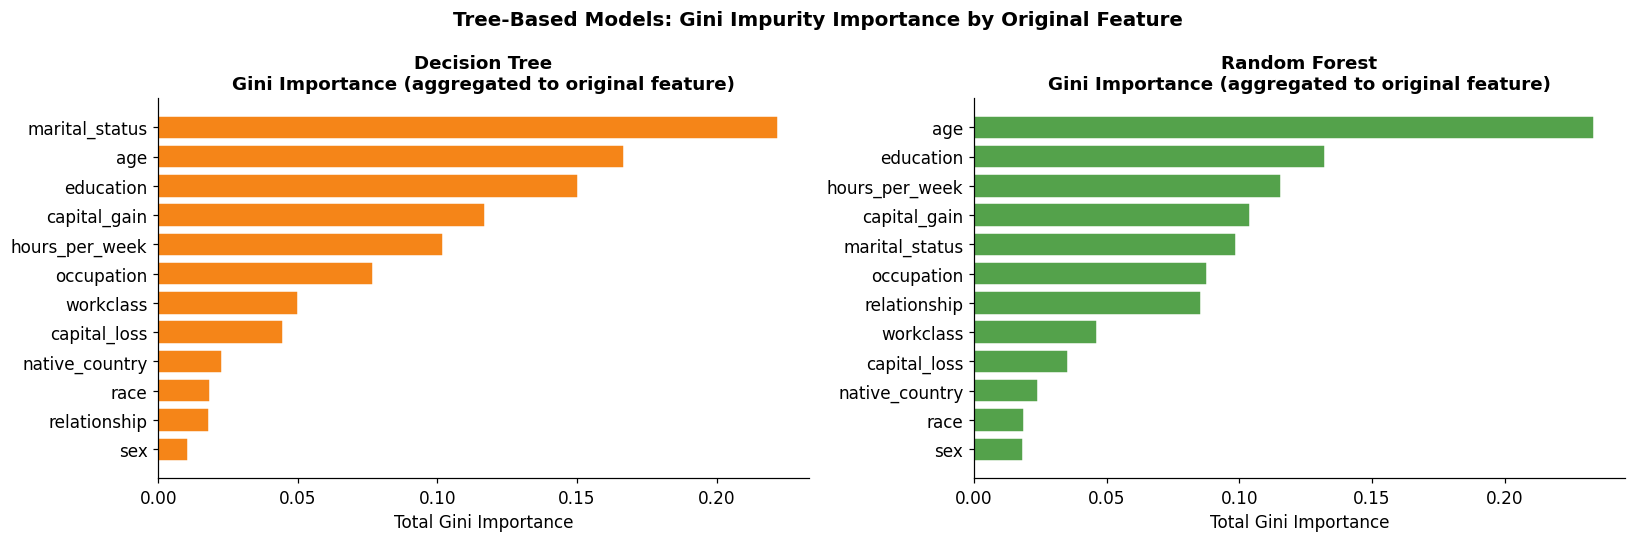

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for i, name in enumerate(['Decision Tree', 'Random Forest']):
    top = tree_imps[name].head(12)
    axes[i].barh(top.index[::-1], top.values[::-1],
                 color=COLOURS[name], edgecolor='white')
    axes[i].set_title(f'{name}\nGini Importance (aggregated to original feature)')
    axes[i].set_xlabel('Total Gini Importance')

plt.suptitle('Tree-Based Models: Gini Impurity Importance by Original Feature',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.3 Permutation Importance — All 3 Models

Permutation importance measures how much the F1 score drops when a feature's values are randomly shuffled. It is model-agnostic and is measured at the original feature level — enabling direct cross-model comparison. Error bars show ±1 standard deviation across 10 shuffles.


In [33]:
# Compute permutation importance for each model
perm_all = []

for name, pipe in fitted.items():
    pi = permutation_importance(
        pipe, X_test, y_test,
        n_repeats=10, random_state=SEED,
        scoring='f1', n_jobs=-1
    )
    perm_all.append(pd.DataFrame({
        'feature':    X_test.columns,
        'importance': pi.importances_mean,
        'std':        pi.importances_std,
        'model':      name
    }))

perm_df = pd.concat(perm_all, ignore_index=True)
print('Permutation importance computed for all 3 models.')


Permutation importance computed for all 3 models.


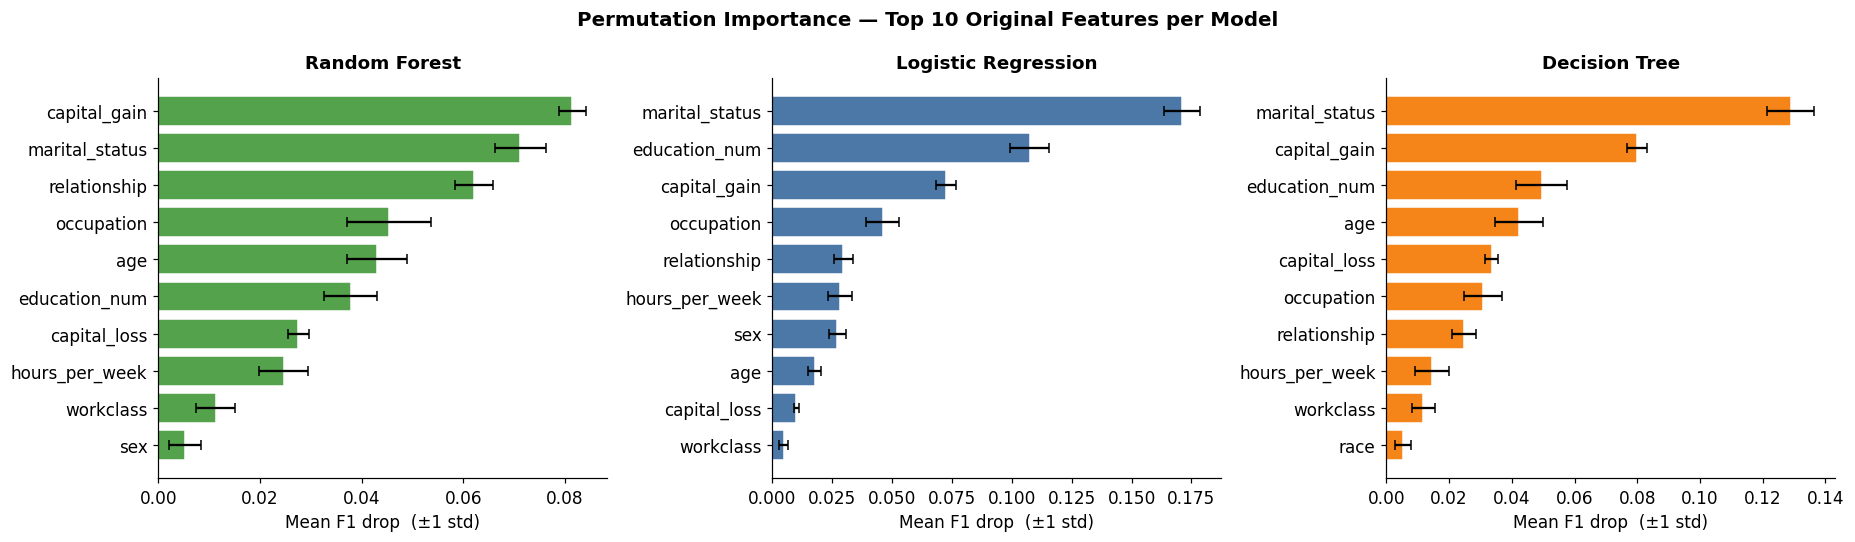

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for i, name in enumerate(model_order):
    sub = perm_df[perm_df['model'] == name].nlargest(10, 'importance')
    axes[i].barh(sub['feature'][::-1], sub['importance'][::-1],
                 xerr=sub['std'][::-1],
                 color=COLOURS[name], edgecolor='white', capsize=3)
    axes[i].set_title(name)
    axes[i].set_xlabel('Mean F1 drop  (±1 std)')

plt.suptitle('Permutation Importance — Top 10 Original Features per Model',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 7.4 Cross-Model Feature Consistency

To answer RQ3, we identify which original features appear in the **top-5** permutation importance ranking for each model. Features appearing across multiple models are robust predictors — not artefacts of one model's assumptions.


In [35]:
# Top-5 per model
top5 = (perm_df.groupby('model', group_keys=False)
        .apply(lambda g: g.nlargest(5, 'importance')))

# Count how many models each feature appears in
consistency = (top5.groupby('feature').size()
               .reset_index(name='models_in_top5')
               .sort_values('models_in_top5', ascending=False))

print('Cross-model consistency (top-5 permutation importance):')
print(consistency.to_string(index=False))


Cross-model consistency (top-5 permutation importance):
       feature  models_in_top5
  capital_gain               3
marital_status               3
           age               2
    occupation               2
 education_num               2
  relationship               2
  capital_loss               1


In [36]:
# Importance rank per model for consistent features
consistent_features = consistency[consistency['models_in_top5'] >= 2]['feature'].tolist()

rank_data = {}
for name in model_order:
    sub = (perm_df[perm_df['model'] == name]
           .sort_values('importance', ascending=False)
           .reset_index(drop=True))
    sub['rank'] = sub.index + 1
    rank_data[name] = sub.set_index('feature')['rank']

rank_df = pd.DataFrame(rank_data).loc[consistent_features]
print('Importance rank per model for features in top-5 of ≥2 models:')
print(rank_df.to_string())


Importance rank per model for features in top-5 of ≥2 models:
                Random Forest  Logistic Regression  Decision Tree
feature                                                          
capital_gain                1                    3              2
marital_status              2                    1              1
age                         5                    8              4
occupation                  4                    4              6
education_num               6                    2              3
relationship                3                    5              7


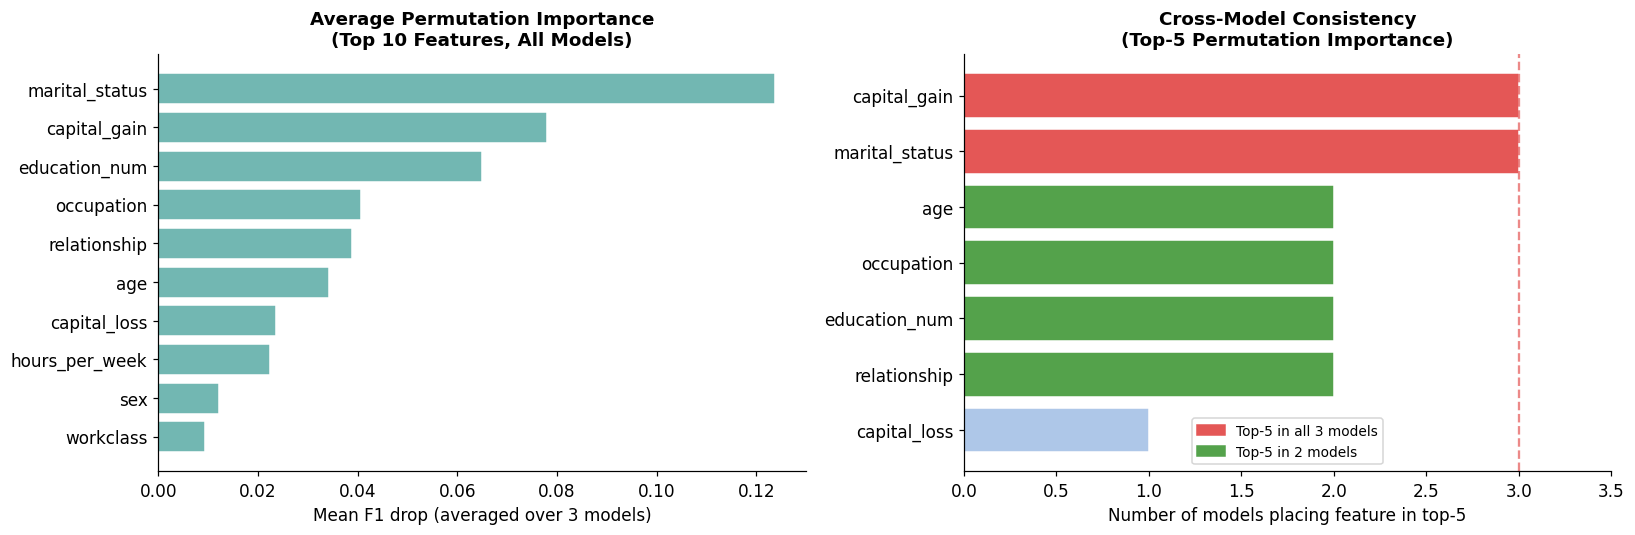

In [37]:
# Average importance across all 3 models
avg_perm = (perm_df.groupby('feature', as_index=False)['importance']
            .mean()
            .sort_values('importance', ascending=False)
            .head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: average importance bar chart
axes[0].barh(avg_perm['feature'][::-1], avg_perm['importance'][::-1],
             color='#72b7b2', edgecolor='white')
axes[0].set_xlabel('Mean F1 drop (averaged over 3 models)')
axes[0].set_title('Average Permutation Importance\n(Top 10 Features, All Models)')

# Right: consistency chart (colour-coded by count)
c_plot = consistency.head(8)
c_colours = ['#e45756' if n == 3 else '#54a24b' if n == 2 else '#aec7e8'
             for n in c_plot['models_in_top5']]
axes[1].barh(c_plot['feature'][::-1], c_plot['models_in_top5'][::-1],
             color=c_colours[::-1], edgecolor='white')
axes[1].set_xlabel('Number of models placing feature in top-5')
axes[1].set_title('Cross-Model Consistency\n(Top-5 Permutation Importance)')
axes[1].set_xlim(0, 3.5)
axes[1].axvline(3, color='#e45756', lw=1.5, ls='--', alpha=0.7)
red_p = mpatches.Patch(color='#e45756', label='Top-5 in all 3 models')
grn_p = mpatches.Patch(color='#54a24b', label='Top-5 in 2 models')
axes[1].legend(handles=[red_p, grn_p], fontsize=9)

plt.tight_layout()
plt.show()


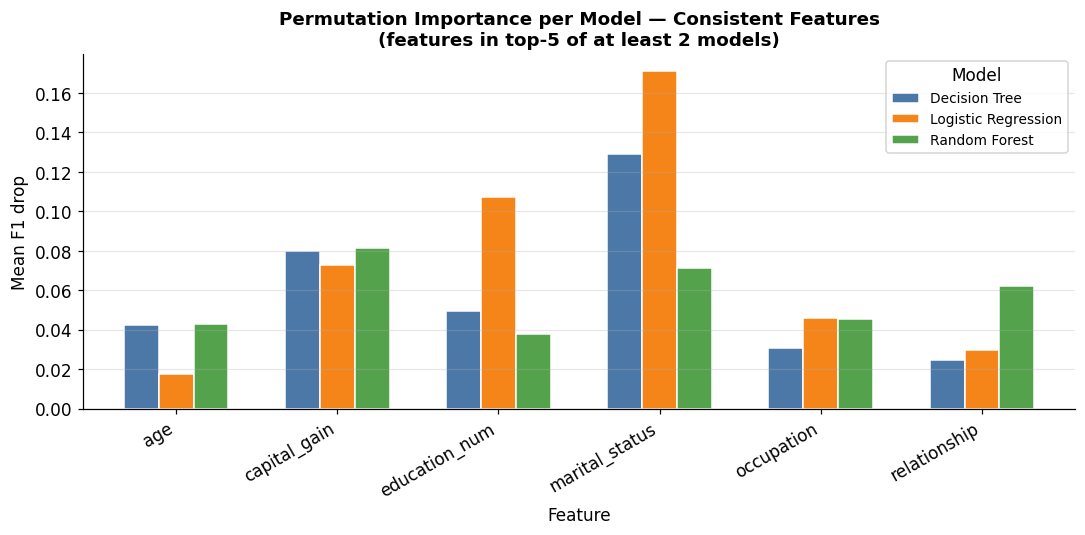

In [38]:
# Per-model comparison for the consistent features
perm_pivot = (perm_df[perm_df['feature'].isin(consistent_features)]
              .pivot(index='feature', columns='model', values='importance'))

ax = perm_pivot.plot(kind='bar', figsize=(10, 5),
                     color=list(COLOURS.values()),
                     edgecolor='white', width=0.65)
ax.set_title('Permutation Importance per Model — Consistent Features\n'
             '(features in top-5 of at least 2 models)',
             fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Mean F1 drop')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Model', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Research Question Answers and Conclusions

---

### RQ1: How accurately can features predict income class?

All three models substantially outperform the majority-class baseline (Accuracy = 0.761, F1 = 0.000). On the 20% hold-out test set:

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Random Forest | 0.8495 | 0.7070 | 0.6403 | **0.6720** | 0.8948 |
| Logistic Regression | 0.8544 | 0.7381 | 0.6129 | 0.6697 | **0.9077** |
| Decision Tree | 0.8171 | 0.6211 | 0.6167 | 0.6189 | 0.7693 |
| **Tuned Random Forest** | **0.8689** | **0.7759** | **0.6403** | **0.7016** | **0.9209** |

The 14 demographic and socio-economic features are genuinely predictive. The best model (tuned Random Forest) achieves **Accuracy = 0.869, F1 = 0.702, ROC-AUC = 0.907** — well above the naive baseline. The remaining error (~30% of >50K individuals misclassified as <=50K) reflects the inherent difficulty of income prediction from demographic features alone.

---

### RQ2: Which model performs best?

**Random Forest is the best model by F1-score (0.6720 base; 0.7016 after tuning)**, and also achieves the best Accuracy after tuning. Logistic Regression achieves the highest ROC-AUC among the **base** models (0.9077). After tuning, the Tuned Random Forest surpasses this with ROC-AUC = 0.9209, making it the overall winner on both F1 and AUC.

Decision Tree performs worst across all metrics, likely due to overfitting: without depth constraints, it memorises training patterns that do not generalise.

**Summary by metric:**

| Metric | Best model |
|--------|-----------|
| F1-score | Tuned Random Forest (0.7016) |
| Accuracy | Tuned Random Forest (0.8689) |
| ROC-AUC | Tuned Random Forest (0.9209) |
| Precision | Tuned Random Forest (0.7759) |

---

### RQ3: Which features are most important, and are they consistent?

Three importance methods (LR coefficients, Gini impurity, permutation importance) consistently identify the same core predictors:

**Features in the top-5 of ALL THREE models (permutation importance):**
- `capital_gain` — strongest single predictor; even a small non-zero capital gain is a powerful >50K signal
- `marital_status` — Married-civ-spouse raises P(>50K) dramatically; the largest positive LR coefficient
- `occupation` — executive, managerial, and professional roles dominate high-income prediction

**Features in the top-5 of TWO models:**
- `age` — older workers accumulate higher salaries on average
- `education_num` — numeric education level; consistent positive LR coefficient

**Cross-model conclusion:** The feature set {`capital_gain`, `marital_status`, `occupation`, `age`, `education_num`} is robust across all model families. These are genuine predictors, not model-specific artefacts.

**Limitations:**
- `education` and `education_num` encode nearly the same information — their combined importance is split across both variables
- Gini importance overestimates `native_country` due to its high cardinality (41 categories → 41 OHE dummies)
- Features such as `sex` and `race` show statistical associations with income in this 1994 dataset, reflecting structural inequalities rather than causal individual factors

---

## 9. Project Summary

| Item | Detail |
|------|--------|
| Dataset | UCI Adult (Census Income) · 32,561 rows · 14 features |
| Missing values | `workclass` (1,836), `occupation` (1,843), `native_country` (583) — handled by pipeline imputation |
| Target | Binary: <=\$50K (76%) vs >\$50K (24%) — moderate class imbalance |
| Train / Test split | 80% / 20%, stratified, `random_state = 42` |
| Preprocessing | Median imputation + StandardScaler (numeric) · Mode imputation + OneHotEncoder (categorical) |
| Models compared | Logistic Regression · Decision Tree · Random Forest (exactly 3) |
| **Best model (F1)** | **Tuned Random Forest** — F1 = 0.7016, Accuracy = 0.8689 |
| **Best model (AUC)** | **Tuned Random Forest** — ROC-AUC = 0.9209 (base: Logistic Regression = 0.9077) |
| Key features | `capital_gain`, `marital_status`, `occupation`, `age`, `education_num` |
| Reproducibility | `random_state = 42` throughout · pipeline prevents all data leakage |
